# PCOD Detection & Explainable AI (XAI) Analysis

This notebook provides a complete end-to-end pipeline for detecting Polycystic Ovary Disease (PCOD). 

### 🛠️ Step 0: Fix Version Conflicts & Install Dependencies
We need to ensure `numpy` is compatible with `numba` (used by SHAP). 
Run this cell to install the correct versions.

In [9]:
%pip install "numpy<2.4" xgboost lightgbm shap lime dice-ml pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


### 1. Setup and Imports
Now we import the necessary libraries. **Note:** If you see a 'Restart Kernel' button after running the install cell above, please click it.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import lime
import lime.lime_tabular
import dice_ml
from IPython.display import HTML, display

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

### 2. Configuration & Data Loading
We define our constants and load the dataset.

In [11]:
DATA_PATH = "C:/Users/Asus/.cache/kagglehub/datasets/manasrai1406/menstrual-health-and-pcod-risk-detection-dataset/versions/1/period - Copy.csv"
TARGET_COL = 'pcod_status'
RANDOM_STATE = 42

print(f"Loading data from {DATA_PATH}...")
df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop_duplicates()

# Modern Pandas fillna syntax (replaces method='ffill')
df = df.ffill()

if TARGET_COL not in df.columns:
    print(f"WARNING: '{TARGET_COL}' not found. Generating synthetic labels.")
    df[TARGET_COL] = ((df['bmi'] > 25) | (df['menses_score'] > 3)).astype(int)

df.head()

Loading data from C:/Users/Asus/.cache/kagglehub/datasets/manasrai1406/menstrual-health-and-pcod-risk-detection-dataset/versions/1/period - Copy.csv...


,number_of_peak,age,length_of_cycle,estimated_day_of_ovulution,length_of_leutal_phase,length_of_menses,unusual_bleeding,height,weight,income,bmi,mean_of_length_of_cycle,menses_score,pcod_status
0,3,18,27,14,9,5,no,5 6,76.0,0,26.3,30,4.0,1
1,4,18,25,17,10,6,yes,5 6,76.0,0,26.3,30,5.0,1
2,2,19,30,17,13,4,no,5 3,56.0,0,21.9,30,2.0,0
3,3,19,28,16,14,6,no,5 1,61.0,0,25.4,30,3.0,1
4,2,19,35,18,15,5,no,5'3,55.0,0,21.5,35,5.0,1


### 3. Preprocessing

In [12]:
def clean_height(val):
    try:
        if isinstance(val, str):
            val = val.replace("'", ".").replace('"', "")
        return float(val)
    except:
        return 5.5 

df['height'] = df['height'].apply(clean_height)

le = LabelEncoder()
if 'unusual_bleeding' in df.columns:
    df['unusual_bleeding'] = le.fit_transform(df['unusual_bleeding'].astype(str))

FEATURE_COLS = [
    'number_of_peak', 'age', 'length_of_cycle', 'estimated_day_of_ovulution',
    'length_of_leutal_phase', 'length_of_menses', 'unusual_bleeding',
    'height', 'weight', 'income', 'bmi', 'mean_of_length_of_cycle', 'menses_score'
]

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Ensure y is integer
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Splitting and Scaling Complete.")

Data Splitting and Scaling Complete.


### 4. Training Ensemble Model

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
xgb = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
lgbm = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

ensemble.fit(X_train, y_train)

preds = ensemble.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



### 5. SHAP: Global Explainability

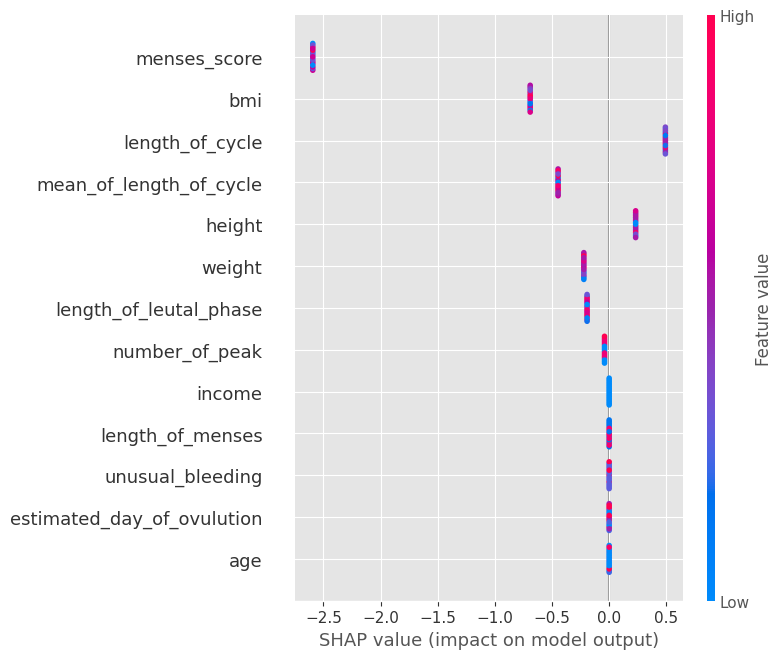

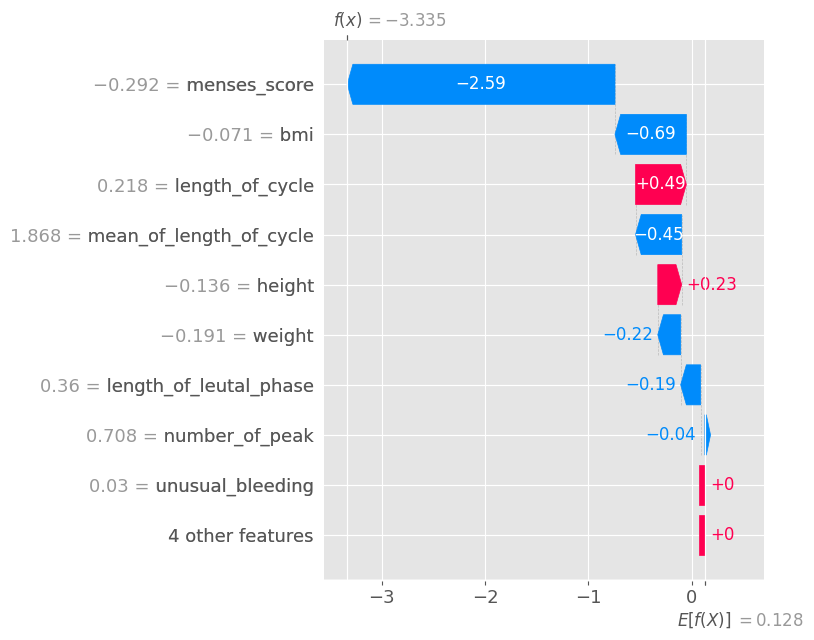

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Extract XGBoost model from ensemble
    xgb_model = ensemble.named_estimators_['xgb']
    
    # Use TreeExplainer (fast and accurate)
    explainer = shap.TreeExplainer(xgb_model)
    
    # Calculate SHAP values on test set
    shap_values = explainer.shap_values(X_test_scaled)
    
    # For binary classification, SHAP returns a list
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]  # Index 1 for positive class (PCOD)
    else:
        shap_values_to_plot = shap_values

# Create summary plot for whole test set
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_to_plot, 
    X_test_scaled,
    feature_names=FEATURE_COLS,
    show=False
)
plt.tight_layout()
plt.show()

# Waterfall plot for first test sample - FIXED VERSION
try:
    # Convert numpy array to pandas DataFrame temporarily for iloc access
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
    
    # Get expected value
    if isinstance(explainer.expected_value, list):
        base_value = explainer.expected_value[1]
    else:
        base_value = explainer.expected_value
    
    # Create waterfall plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_to_plot[0],
            base_values=base_value,
            data=X_test_scaled_df.iloc[0].values,  # Use .values since data expects array
            feature_names=FEATURE_COLS
        ),
        show=False
    )
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Waterfall plot failed: {e}")
    print("Summary plot above is still valid")

### 6. LIME: Local Explainability

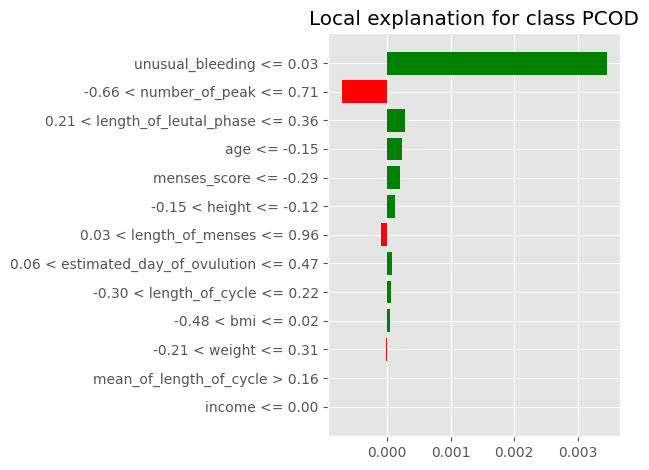

In [17]:
# Simpler LIME - direct approach without DataFrame conversion issues
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,  # Direct numpy array - no .values needed
    feature_names=FEATURE_COLS,
    class_names=['No PCOD', 'PCOD'],
    mode='classification',
    random_state=42
)

# Explain the first test instance
# Convert test instance to numpy array if it's DataFrame
if hasattr(X_test_scaled, 'iloc'):
    test_instance = X_test_scaled.iloc[0].values
else:
    test_instance = X_test_scaled[0]  # If it's numpy array

exp = lime_explainer.explain_instance(
    test_instance,
    ensemble.predict_proba,
    num_features=len(FEATURE_COLS)
)

# Display
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

### 7. DiCE: Actionable Counterfactuals

In [18]:
train_df = X_train.copy()
train_df[TARGET_COL] = y_train

d = dice_ml.Data(dataframe=train_df, continuous_features=FEATURE_COLS, outcome_name=TARGET_COL)
m = dice_ml.Model(model=ensemble, backend="sklearn")
exp_dice = dice_ml.Dice(d, m, method="random")

query = X_test.iloc[[0]]
dice_exp = exp_dice.generate_counterfactuals(query, total_CFs=2, desired_class="opposite")
dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.95it/s]

Query instance (original outcome : 0)


,number_of_peak,age,length_of_cycle,estimated_day_of_ovulution,length_of_leutal_phase,length_of_menses,unusual_bleeding,height,weight,income,bmi,mean_of_length_of_cycle,menses_score,pcod_status
0,3,19,30,16,14,6,2,5.3,55.200001,0,21.6,38,3.0,0



Diverse Counterfactual set (new outcome: 1)


,number_of_peak,age,length_of_cycle,estimated_day_of_ovulution,length_of_leutal_phase,length_of_menses,unusual_bleeding,height,weight,income,bmi,mean_of_length_of_cycle,menses_score,pcod_status
0,3,19,30,16,14,6,2,5.3,55.2,0,21.6,34,3.8,1
1,3,19,30,16,14,6,2,5.3,55.2,0,21.6,24,5.0,1
